In [1]:
import os
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import timm
from sklearn.preprocessing import label_binarize

In [3]:
# 1. Load and preprocess the dataset
dataset_path = "archive/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"
categories = ["Bengin cases", "Malignant cases", "Normal cases"]

In [4]:

data = []
labels = []

for category in categories:
    folder_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (224, 224))
            data.append(img)
            labels.append(category)

# Convert to arrays and normalize
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(labels)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Binarize for ROC later
y_binarized = label_binarize(y_encoded, classes=[0, 1, 2])

In [6]:
# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")


Train shape: (767, 224, 224, 3), Validation shape: (165, 224, 224, 3), Test shape: (165, 224, 224, 3)


In [7]:


# Convert to tensors (NCHW format)
X_train_t = torch.tensor(X_train).permute(0, 3, 1, 2)
X_val_t = torch.tensor(X_val).permute(0, 3, 1, 2)
X_test_t = torch.tensor(X_test).permute(0, 3, 1, 2)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Create Dataloaders
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

# 2. Load ViT model from timm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=3)
model.to(device)

# 3. Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-1)



In [8]:
# 4. Training loop with history tracking
num_epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation accuracy
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            _, predicted = torch.max(outputs.data, 1)
            total += yb.size(0)
            correct += (predicted == yb).sum().item()
    val_acc = correct / total
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")

# 5. Evaluate on Test Set
model.eval()
y_true, y_pred, y_scores = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        _, predicted = torch.max(outputs.data, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(yb.numpy())
        y_scores.extend(outputs.cpu().numpy())



Epoch 1/10 - Loss: 43.0924, Val Acc: 0.5091
Epoch 2/10 - Loss: 29.6988, Val Acc: 0.5091
Epoch 3/10 - Loss: 32.3529, Val Acc: 0.5091
Epoch 4/10 - Loss: 11.7434, Val Acc: 0.3818
Epoch 5/10 - Loss: 2.0355, Val Acc: 0.3818
Epoch 6/10 - Loss: 1.2625, Val Acc: 0.5091
Epoch 7/10 - Loss: 1.0763, Val Acc: 0.5091
Epoch 8/10 - Loss: 0.9925, Val Acc: 0.5091
Epoch 9/10 - Loss: 0.9989, Val Acc: 0.5091
Epoch 10/10 - Loss: 1.0799, Val Acc: 0.5091


In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, matthews_corrcoef)
import numpy as np

# Collect predictions
model.eval()
y_true, y_pred, y_scores = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        _, predicted = torch.max(outputs.data, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(yb.numpy())
        y_scores.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# AUC (multi-class)
try:
    auc_score = roc_auc_score(y_true, y_scores, multi_class='ovr', average='weighted')
except:
    auc_score = float('nan')

mcc = matthews_corrcoef(y_true, y_pred)

vit_metrics = {
    'Accuracy': round(accuracy_score(y_true, y_pred), 4),
    'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
    'Recall': round(recall_score(y_true, y_pred, average='weighted'), 4),
    'F1 Score': round(f1_score(y_true, y_pred, average='weighted'), 4),
    'AUC': round(auc_score, 4),
    'MCC': round(mcc, 4)
}

print("\nVision Transformer Evaluation Metrics:")
for key, value in vit_metrics.items():
    print(f"{key}: {value}")



Vision Transformer Evaluation Metrics:
Accuracy: 0.5152
Precision: 0.2654
Recall: 0.5152
F1 Score: 0.3503
AUC: nan
MCC: 0.0


/Users/proshadmohonto/Desktop/defense_work/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


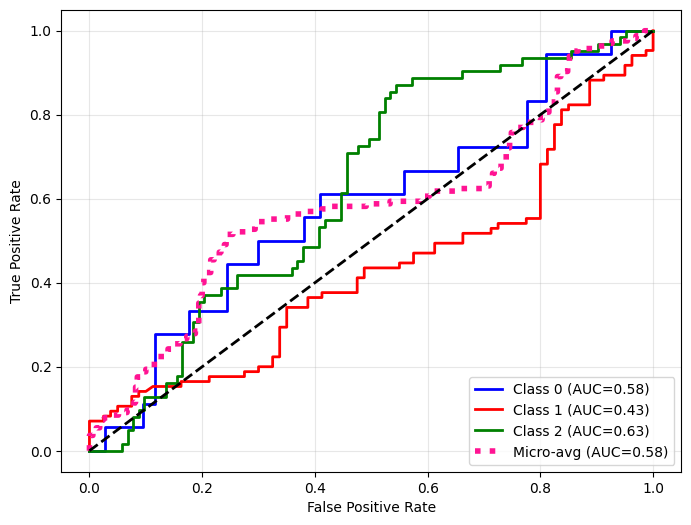

In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = y_scores.shape[1]
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot
plt.figure(figsize=(8,6))
colors = ['blue', 'red', 'green']  # adjust for number of classes
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i} (AUC={roc_auc[i]:.2f})")

plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-avg (AUC={roc_auc['micro']:.2f})",
         color="deeppink", linestyle=":", linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


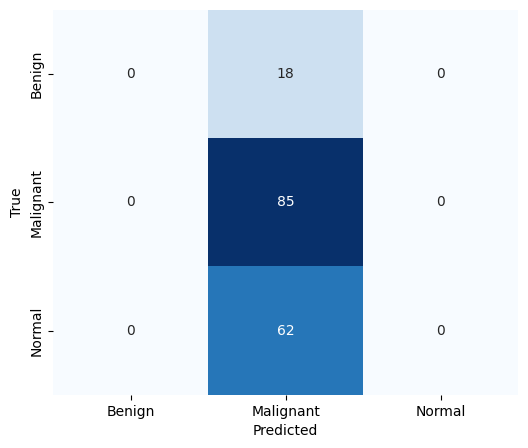

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

categories = ["Benign", "Malignant", "Normal"]  # adjust your classes
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories, cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("")
plt.show()



Classification Report:
                 precision    recall  f1-score   support

   Bengin cases     0.0000    0.0000    0.0000        18
Malignant cases     0.5152    1.0000    0.6800        85
   Normal cases     0.0000    0.0000    0.0000        62

       accuracy                         0.5152       165
      macro avg     0.1717    0.3333    0.2267       165
   weighted avg     0.2654    0.5152    0.3503       165


Confusion Matrix:


/Users/proshadmohonto/Desktop/defense_work/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/proshadmohonto/Desktop/defense_work/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/proshadmohonto/Desktop/defense_work/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

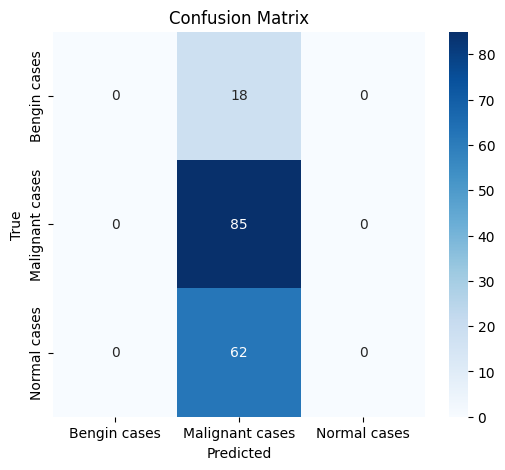

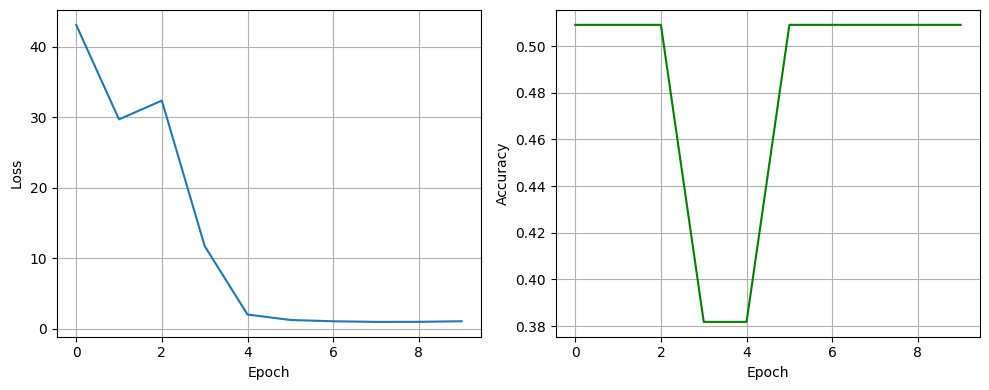

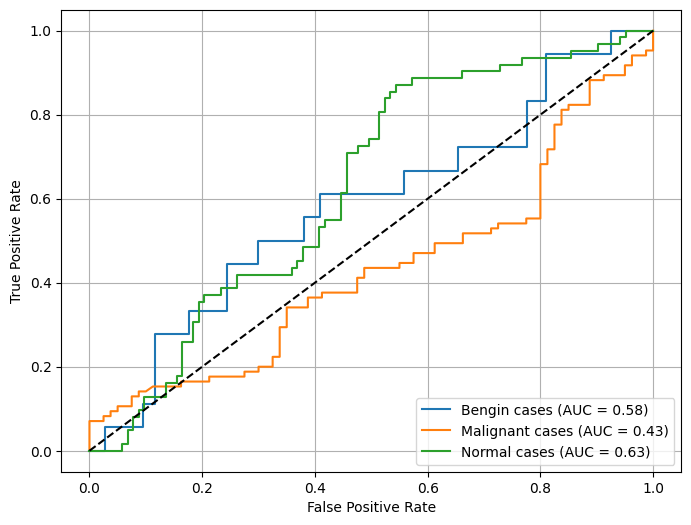

In [14]:
# 6. Metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 7. Plot Training Loss and Validation Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title("")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', color='green')
plt.title("")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. ROC Curve for Multiclass
y_test_binarized = label_binarize(y_true, classes=[0, 1, 2])
y_scores_np = np.array(y_scores)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_scores_np[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in enumerate(le.classes_):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()